In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LassoCV, LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler



In [2]:
# Set aesthetic visual style
sns.set_theme(style="whitegrid")

# 1. Data Preparation
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
X = df.drop(columns="sepal length (cm)")
y = df["sepal length (cm)"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 2. Models with Dynamic Regularization Tuning (CV Alphas)
alphas = np.logspace(-3, 2, 100)

models = {
    "Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), RidgeCV(alphas=alphas)),
    "Lasso": make_pipeline(
        StandardScaler(), LassoCV(alphas=alphas, random_state=42, max_iter=10000)
    ),
}

In [3]:
# 3. Model Training & Test Evaluation
results, coefs, predictions = [], {}, {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred

    # Extract regressor step from pipeline
    regressor = model.steps[-1][1]
    coefs[name] = regressor.coef_

    # Get tuned alpha if applicable
    best_alpha = getattr(regressor, "alpha_", None)

    results.append(
        {
            "Model": name,
            "Best Alpha": round(best_alpha, 4) if best_alpha else "N/A",
            "MSE": mean_squared_error(y_test, pred),
            "MAE": mean_absolute_error(y_test, pred),
            "R2": r2_score(y_test, pred),
        }
    )

results_df = pd.DataFrame(results)
coef_df = pd.DataFrame(coefs, index=X.columns)

print("=== Model Performance ===")
print(results_df.to_string(index=False))
print("\n=== Standardized Coefficients ===")
print(coef_df.round(3))

# 4. Cross-Validation Evaluation
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="r2")
    for score in scores:
        cv_results.append({"Model": name, "R2 Score": score})

cv_df = pd.DataFrame(cv_results)

=== Model Performance ===
 Model Best Alpha      MSE      MAE       R2
Linear        N/A 0.102126 0.234129 0.852048
 Ridge     0.0933 0.100923 0.232957 0.853792
 Lasso      0.001 0.100330 0.232391 0.854650

=== Standardized Coefficients ===
                   Linear  Ridge  Lasso
sepal width (cm)    0.297  0.295  0.293
petal length (cm)   1.322  1.301  1.291
petal width (cm)   -0.505 -0.485 -0.476


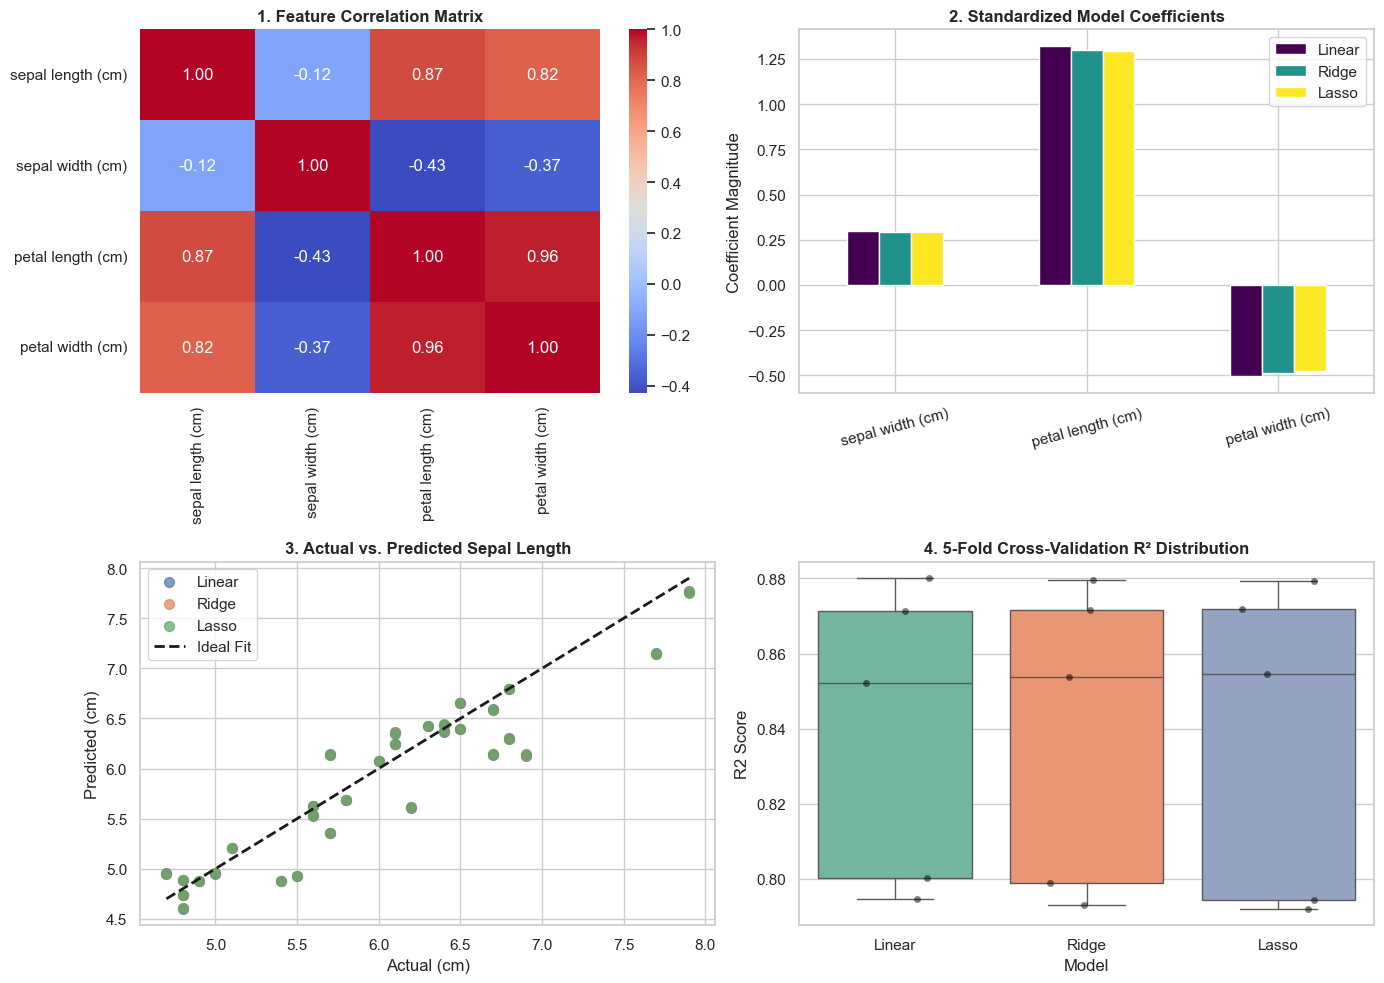

In [4]:
# 5. Visualizations (2x2 Dashboard)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Feature Correlation Heatmap
sns.heatmap(
    df.corr(), annot=True, cmap="coolwarm", fmt=".2f", ax=axes[0, 0], cbar=True
)
axes[0, 0].set_title("1. Feature Correlation Matrix", fontsize=12, fontweight="bold")

# Plot 2: Model Coefficients Comparison
coef_df.plot(kind="bar", ax=axes[0, 1], colormap="viridis")
axes[0, 1].set_title(
    "2. Standardized Model Coefficients", fontsize=12, fontweight="bold"
)
axes[0, 1].set_ylabel("Coefficient Magnitude")
axes[0, 1].tick_params(axis="x", rotation=15)

# Plot 3: Actual vs. Predicted Values
for name, pred in predictions.items():
    axes[1, 0].scatter(y_test, pred, label=name, alpha=0.7, s=50)
axes[1, 0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "k--",
    lw=2,
    label="Ideal Fit",
)
axes[1, 0].set_title(
    "3. Actual vs. Predicted Sepal Length", fontsize=12, fontweight="bold"
)
axes[1, 0].set_xlabel("Actual (cm)")
axes[1, 0].set_ylabel("Predicted (cm)")
axes[1, 0].legend()

# Plot 4: 5-Fold Cross-Validation Distribution
sns.boxplot(
    x="Model", y="R2 Score", data=cv_df, ax=axes[1, 1], palette="Set2", hue="Model"
)
sns.stripplot(
    x="Model",
    y="R2 Score",
    data=cv_df,
    ax=axes[1, 1],
    color="black",
    alpha=0.5,
    jitter=0.2,
)
axes[1, 1].set_title(
    "4. 5-Fold Cross-Validation R² Distribution", fontsize=12, fontweight="bold"
)

plt.tight_layout()
plt.savefig("iris_regression_dashboard.png", dpi=300)
plt.show()